Baseline

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from narwhals import Categorical
from narwhals.selectors import categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix
from lightgbm.callback import early_stopping, log_evaluation


import lightgbm as lgb

In [2]:
path_to_data = "/home/usl/PycharmProjects/home-credit-default-risk/data/raw/home-credit-default-risk/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")
application_test_df = pd.read_csv(path_to_data+"application_test.csv")

Split into train and val

In [3]:
train_users = application_train_df["SK_ID_CURR"].unique()
train_ids, val_ids = train_test_split(train_users, test_size=0.2, random_state=42)
train_ids

array([243191, 111778, 175057, ..., 253016, 270275, 241394],
      shape=(246008,))

In [4]:
train_df = application_train_df[application_train_df.SK_ID_CURR.isin(train_ids)].copy()
val_df = application_train_df[application_train_df.SK_ID_CURR.isin(val_ids)].copy()

In [5]:
train_df.shape, val_df.shape

((246008, 122), (61503, 122))

In [6]:
application_train_df["TARGET"].mean(), train_df["TARGET"].mean(), val_df["TARGET"].mean()

(np.float64(0.08072881945686496),
 np.float64(0.08079412051640597),
 np.float64(0.08046761946571712))

In [7]:
drop_feat = ["SK_ID_CURR"]
train_df.drop(drop_feat, axis=1, inplace=True)
val_df.drop(drop_feat, axis=1, inplace=True)
application_test_df.drop(drop_feat, axis=1, inplace=True)

In [8]:
X_train = train_df.drop("TARGET", axis=1)
y_train = train_df["TARGET"]
X_val = val_df.drop("TARGET", axis=1)
y_val = val_df["TARGET"]

In [11]:
cat_cols = X_train.select_dtypes(include = 'object').columns.tolist()
len(cat_cols)

16

In [13]:
for col in cat_cols:
    categories = X_train[col].dropna().unique()
    X_train[col] = pd.Categorical(X_train[col], categories = categories)
    X_val[col] = pd.Categorical(X_val[col], categories = categories)


In [14]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

### LightGBM

In [29]:
lgb_clf = lgb.LGBMClassifier(n_estimators=1000, max_depth=4, learning_rate=0.1, random_state = 42, n_jobs=-1)
lgb_clf.fit(X_train, y_train, eval_set = [(X_val, y_val)], eval_metric='auc', categorical_feature=cat_cols, callbacks = [early_stopping(stopping_rounds=100), log_evaluation(period = 100)])

threshold = 0.5
val_pred_proba = lgb_clf.predict_proba(X_val)[:, 1]
val_pred = (val_pred_proba >= threshold).astype(int)


roc_auc_lgb = roc_auc_score(y_val, val_pred_proba)
prec_lgb = precision_score(y_val, val_pred, zero_division=0)
rec_lgb = recall_score(y_val, val_pred, zero_division=0)

print("Best_iteration:", lgb_clf.best_iteration_)
print("ROC-AUC_lgb:", roc_auc_lgb)
print("Precision_lgb:", prec_lgb)
print("Recall_lgb:", rec_lgb)

/home/usl/PycharmProjects/home-credit-default-risk/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11315
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 116
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

Text(0.5, 1.0, 'Confusion Matrix LightGBM')

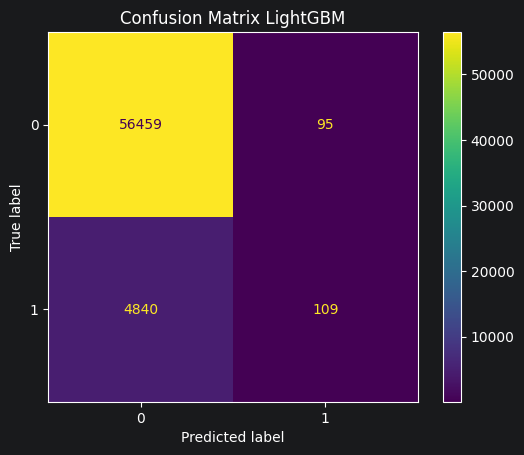

In [26]:
ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Confusion Matrix LightGBM")